# Student Performance Prediction

## Objective
Predict student exam performance based on study habits, attendance, parental involvement, and other academic factors.

# Import the required libraries

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


# Objective
Import the  dataset csv file and access it using the pandas library

In [3]:
db = pd.read_csv("Student_performance_data _.csv")

# Objective
Check the data of csv file number of columns and top 5 entries

In [4]:
print("Output")
print(db.head())

Output
   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1          

print the details of every column its data type, Not-Null Count,column name

In [5]:
db.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


print the number of null values in each column

# Objective
convert every heading to capital for better accessing

In [6]:
db.columns = db.columns.str.upper()

In [7]:
print(db.isnull().sum())
print("-----------------------------------------------")
print("Duplicate Values", db.duplicated().sum())

STUDENTID            0
AGE                  0
GENDER               0
ETHNICITY            0
PARENTALEDUCATION    0
STUDYTIMEWEEKLY      0
ABSENCES             0
TUTORING             0
PARENTALSUPPORT      0
EXTRACURRICULAR      0
SPORTS               0
MUSIC                0
VOLUNTEERING         0
GPA                  0
GRADECLASS           0
dtype: int64
-----------------------------------------------
Duplicate Values 0


# Key Observation
- There are no null values in any column
- there are no duplicate entries in the dataset

describe each column using different aspacts

In [8]:
db.describe()

,STUDENTID,AGE,GENDER,ETHNICITY,PARENTALEDUCATION,STUDYTIMEWEEKLY,ABSENCES,TUTORING,PARENTALSUPPORT,EXTRACURRICULAR,SPORTS,MUSIC,VOLUNTEERING,GPA,GRADECLASS
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


# Objective

plot a histogram of the data based on GPA to check the average GPA distribution
data is plot on 0.5 GPA gaps 

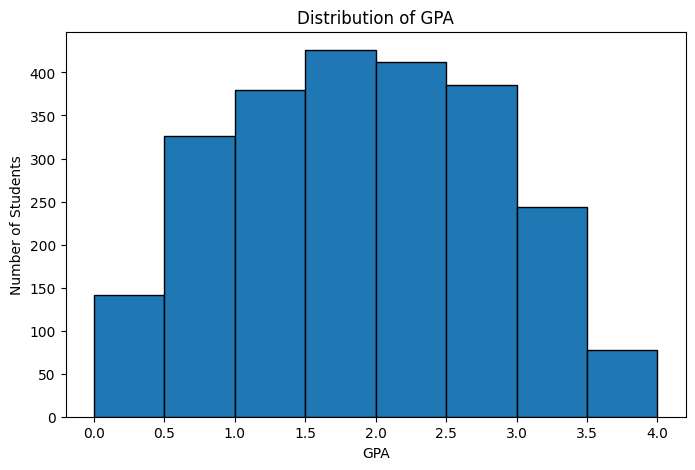

In [9]:
plt.figure(figsize=(8,5))
plt.hist(db["GPA"], bins = 8, edgecolor="black")
plt.title("Distribution of GPA")
plt.xlabel("GPA")
plt.ylabel("Number of Students")
plt.show()

# Key Observation
- Data is concentrated towards centre and is not skewed at either side
- maximum student have GPA between 1.5 to 2.0
- there are minimum student who have GPA greater than 3.5

# Objective

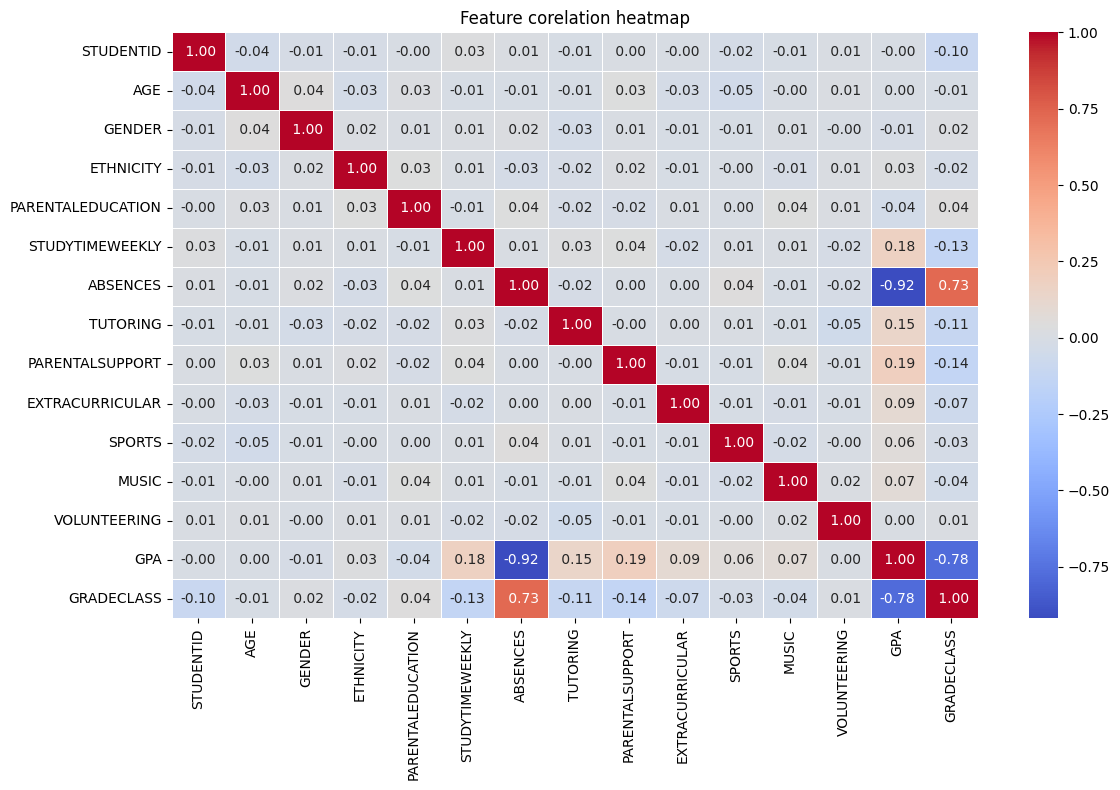

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(
    db.corr(),
    annot=True,
    fmt = " .2f",
    cmap="coolwarm",
    linewidths= 0.5
)
plt.title('Feature corelation heatmap')
plt.tight_layout()
plt.savefig("Corelation_heatmap.png", dpi = 150)
plt.show()


In [11]:
target_col = 'GRADECLASS'
correlations = db.corr()[target_col].drop(target_col)
print(correlations.sort_values(ascending=False))

ABSENCES             0.728633
PARENTALEDUCATION    0.041031
GENDER               0.022998
VOLUNTEERING         0.013156
AGE                 -0.006250
ETHNICITY           -0.023326
SPORTS              -0.026654
MUSIC               -0.036065
EXTRACURRICULAR     -0.069733
STUDENTID           -0.098500
TUTORING            -0.111695
STUDYTIMEWEEKLY     -0.134131
PARENTALSUPPORT     -0.136823
GPA                 -0.782835
Name: GRADECLASS, dtype: float64


# Output
EDA identifies that Absence and Parental support are dominant pridictor of student grade class (r = '0.72' r = '-0.13') and student grade class does not depend on Student ID 

In [12]:
training_model = db.drop(columns=['STUDENTID', 'GRADECLASS', 'GPA'])
Testing = db['GRADECLASS']

print(training_model.shape)
print(training_model.columns)


(2392, 12)
Index(['AGE', 'GENDER', 'ETHNICITY', 'PARENTALEDUCATION', 'STUDYTIMEWEEKLY',
       'ABSENCES', 'TUTORING', 'PARENTALSUPPORT', 'EXTRACURRICULAR', 'SPORTS',
       'MUSIC', 'VOLUNTEERING'],
      dtype='str')


In [13]:
training_model_train, training_model_test, Testing_train, Testing_test = train_test_split(
    training_model, Testing, test_size= 0.25, random_state= 42
)
print(training_model_train.shape, training_model_test.shape)

(1794, 12) (598, 12)


In [14]:
print(Testing.value_counts())
print(Testing.value_counts(normalize=True).round(2))

GRADECLASS
4.0    1211
3.0     414
2.0     391
1.0     269
0.0     107
Name: count, dtype: int64
GRADECLASS
4.0    0.51
3.0    0.17
2.0    0.16
1.0    0.11
0.0    0.04
Name: proportion, dtype: float64


In [15]:
scaler = StandardScaler()

training_model_train_scaled = scaler.fit_transform(training_model_train)
training_model_test_scaled = scaler.transform(training_model_test)

print("training_model_train_scaled: ", training_model_train_scaled)
print("training_model_test_scaled: ", training_model_test_scaled)

training_model_train_scaled:  [[-0.40981171 -1.02827012 -0.84340457 ... -0.6588268   2.00980741
  -0.42640143]
 [ 0.48242398  0.9725071   0.1283795  ... -0.6588268  -0.49756011
  -0.42640143]
 [-0.40981171  0.9725071  -0.84340457 ... -0.6588268  -0.49756011
  -0.42640143]
 ...
 [-0.40981171  0.9725071  -0.84340457 ...  1.5178496  -0.49756011
  -0.42640143]
 [ 1.37465967 -1.02827012  2.07194765 ... -0.6588268  -0.49756011
  -0.42640143]
 [ 1.37465967 -1.02827012  0.1283795  ... -0.6588268  -0.49756011
  -0.42640143]]
training_model_test_scaled:  [[-1.3020474   0.9725071   1.10016358 ...  1.5178496   2.00980741
   2.34520788]
 [-0.40981171  0.9725071  -0.84340457 ... -0.6588268  -0.49756011
   2.34520788]
 [-1.3020474  -1.02827012 -0.84340457 ... -0.6588268  -0.49756011
   2.34520788]
 ...
 [-1.3020474   0.9725071   0.1283795  ... -0.6588268  -0.49756011
  -0.42640143]
 [-0.40981171 -1.02827012  0.1283795  ... -0.6588268  -0.49756011
  -0.42640143]
 [-0.40981171 -1.02827012  2.07194765 .

In [16]:
lr_model = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(training_model_train_scaled, Testing_train)

lr_pred = lr_model.predict(training_model_test_scaled)


In [17]:
accuracy = accuracy_score(Testing_test, lr_pred)
print("accuracy", accuracy*100)
print(classification_report(Testing_test, lr_pred))

accuracy 58.19397993311036
              precision    recall  f1-score   support

         0.0       0.13      0.36      0.19        28
         1.0       0.30      0.26      0.28        68
         2.0       0.44      0.34      0.39       105
         3.0       0.43      0.53      0.47       104
         4.0       0.92      0.78      0.85       293

    accuracy                           0.58       598
   macro avg       0.44      0.46      0.43       598
weighted avg       0.64      0.58      0.60       598



logistic regression marks a accuracy of 58.19% with a weighted f1-score of 0.60. the model performs well on majority class but less precise with minority class (4.0 >50% of dataset and precision of 92%). this suggest the linear decision boundaries are insufficient for the complex analysis of student grade

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(training_model_train,Testing_train)
rf_predict = rf_model.predict(training_model_test)


In [19]:
print("Accuracy: ", accuracy_score(Testing_test, rf_predict))
print(classification_report(Testing_test,rf_predict))

Accuracy:  0.68561872909699
              precision    recall  f1-score   support

         0.0       0.33      0.18      0.23        28
         1.0       0.47      0.49      0.48        68
         2.0       0.52      0.51      0.52       105
         3.0       0.51      0.59      0.55       104
         4.0       0.89      0.88      0.88       293

    accuracy                           0.69       598
   macro avg       0.54      0.53      0.53       598
weighted avg       0.68      0.69      0.68       598



# XGBOOST Model

In [20]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    objective = 'multi:softmax',
    num_class = 5,
    random_state = 42,
    eval_metric = 'logloss'
)
xgb_model.fit(training_model_train,Testing_train)

xgb_pred = xgb_model.predict(training_model_test)

In [21]:
print("accuracy", accuracy_score(Testing_test, xgb_pred))
print(classification_report(Testing_test, xgb_pred))

accuracy 0.6906354515050167
              precision    recall  f1-score   support

         0.0       0.55      0.21      0.31        28
         1.0       0.46      0.41      0.43        68
         2.0       0.50      0.53      0.52       105
         3.0       0.54      0.49      0.51       104
         4.0       0.85      0.93      0.89       293

    accuracy                           0.69       598
   macro avg       0.58      0.52      0.53       598
weighted avg       0.68      0.69      0.68       598



# ROC AUC SCORE

In [22]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(Testing_test, classes=[0,1,2,3,4])

xgb_proba = xgb_model.predict_proba(training_model_test)
xgb_auc = roc_auc_score(y_test_bin, xgb_proba, multi_class='ovr', average='macro')
print(f"XGBoost ROC-AUC: {xgb_auc:.3f}")


rf_proba = rf_model.predict_proba(training_model_test)
rf_auc = roc_auc_score(y_test_bin, rf_proba, multi_class='ovr', average='macro')
print(f"Fandom forest ROC-AUC: {rf_auc:.3f}")


XGBoost ROC-AUC: 0.853
Fandom forest ROC-AUC: 0.854


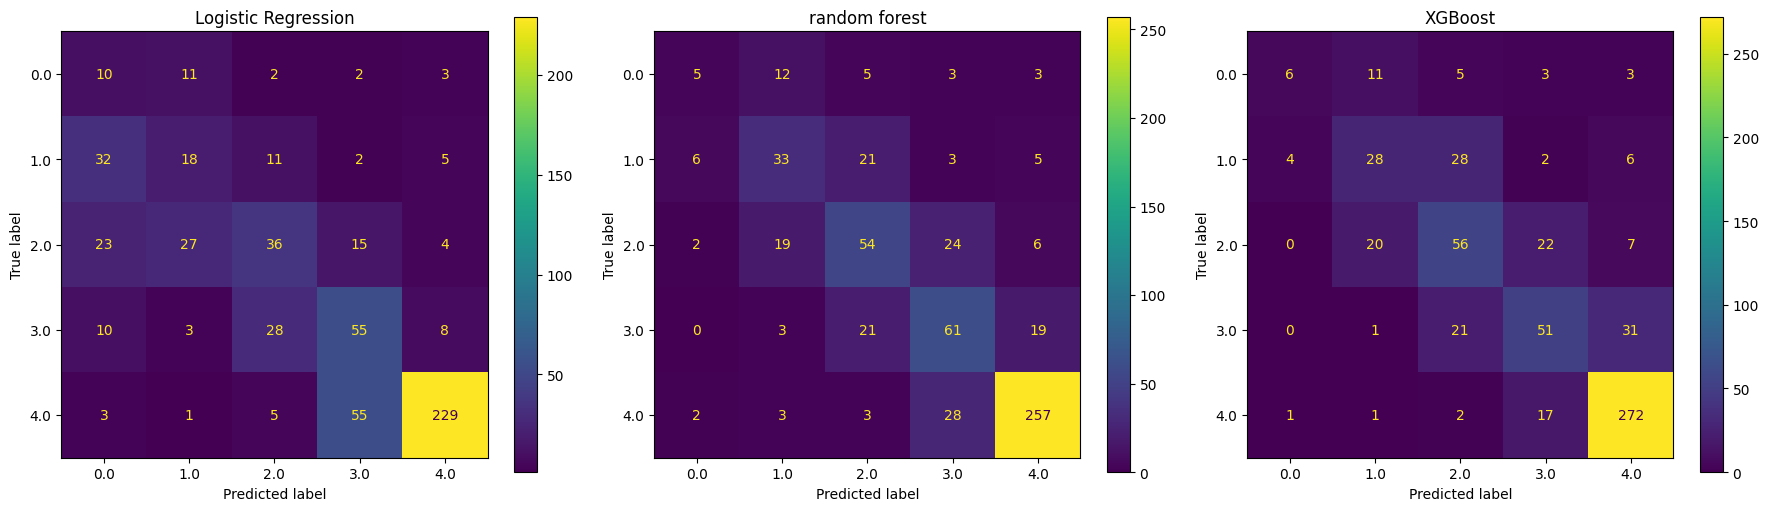

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(1,3,figsize = (18,5))
for ax, model, preds, title in zip(
    axes,
    [lr_model, rf_model, xgb_model],
    [lr_pred, rf_predict, xgb_pred],
    ['Logistic Regression', 'random forest', 'XGBoost']
):
    ConfusionMatrixDisplay.from_predictions(Testing_test, preds, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi = 150)
plt.show()

In [26]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(training_model_test)
print(type(shap_values))


<class 'numpy.ndarray'>


In [27]:
import numpy as np
print(np.array(shap_values).shape)


(598, 12, 5)


<function matplotlib.pyplot.show(close=None, block=None)>

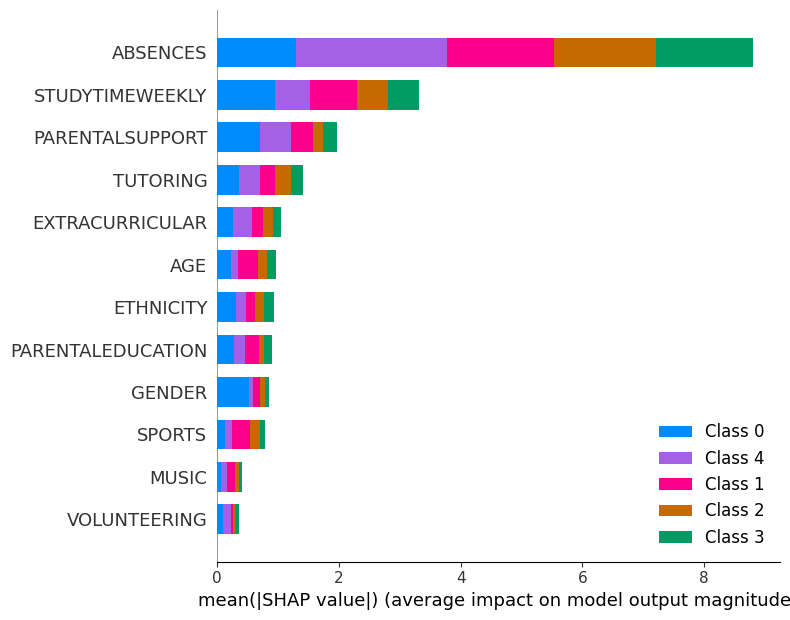

In [38]:
shap.summary_plot(
    shap_values,
    training_model_test,
    feature_names = training_model_test.columns,
    plot_type ="bar",
    show = False
    )
plt.tight_layout()
plt.savefig("summary_plot.png", dpi = 300, bbox_inches="tight")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

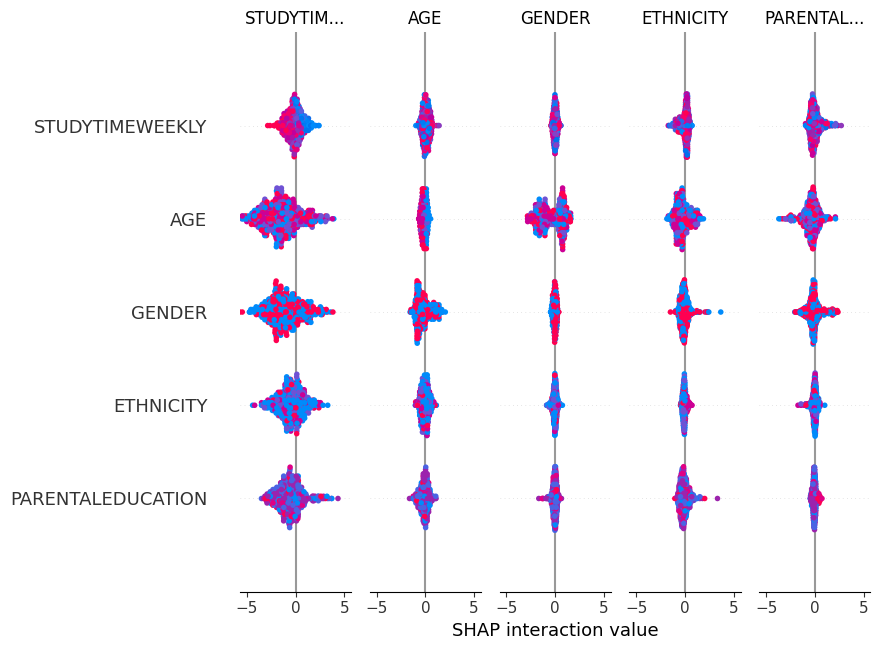

In [39]:
shap.summary_plot(
    shap_values,
    training_model_test,
    feature_names = training_model_test.columns,
    show = False
)
plt.tight_layout()
plt.savefig("Global_summary.png", dpi = 300, bbox_inches = "tight")
plt.show

In [41]:
importance = pd.DataFrame({
    'feature': training_model_train.columns,
    'Importance': xgb_model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
print(importance)

              feature  Importance
5            ABSENCES    0.261206
6            TUTORING    0.100277
7     PARENTALSUPPORT    0.088257
9              SPORTS    0.072896
10              MUSIC    0.070999
11       VOLUNTEERING    0.070512
8     EXTRACURRICULAR    0.066352
4     STUDYTIMEWEEKLY    0.061850
2           ETHNICITY    0.054292
1              GENDER    0.053774
3   PARENTALEDUCATION    0.051727
0                 AGE    0.047858


In [42]:
importance.to_csv(
    "XGBoost_feature_importance.csv",
    index=False
)
